# 2-Stage Model Performance Evaluation

This notebook evaluates our new **2-Stage Classification Strategy**.

**The Strategy:**
1.  **Stage 1**: Predict Direction (Down, Neutral, Up).
2.  **Stage 2**: 
    *   If Stage 1 is **Up**, predict Magnitude (Moderate Up vs Strong Up).
    *   If Stage 1 is **Down**, predict Magnitude (Moderate Down vs Strong Down).

This approach allows specialized models to focus on specific market conditions.

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- Path Setup ---
current_dir = os.getcwd()
src_path = os.path.join(current_dir, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from Feature_Engineering import prepare_training_data, DB_PATH
# Import create_labels to ensure we use the same logic for ground truth
from Model_Training import create_labels

## 1. Load Models and Data

We need to load all three models: Stage 1, Stage 2 Up, and Stage 2 Down.

In [7]:
STOCK_ID = '2497'
MODELS_DIR = 'models'
DB_FULL_PATH = os.path.abspath(os.path.join('data', 'twstock.db'))
TARGET_DAYS = 3

# Load Models
try:
    model_s1 = joblib.load(os.path.join(MODELS_DIR, f'xgb_stage1_{STOCK_ID}.pkl'))
    model_s2_up = joblib.load(os.path.join(MODELS_DIR, f'xgb_stage2_up_{STOCK_ID}.pkl'))
    model_s2_down = joblib.load(os.path.join(MODELS_DIR, f'xgb_stage2_down_{STOCK_ID}.pkl'))
    print("All 3 models loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading models: {e}")
    print("Please run src/Model_Training.py first.")
    model_s1 = None

# Load Data
print(f"Loading data from {DB_FULL_PATH}...")
df = prepare_training_data(STOCK_ID, target_days=TARGET_DAYS, path=DB_FULL_PATH)

if df is not None and not df.empty:
    # Create Ground Truth Labels (using the same function as training)
    df = create_labels(df)
    
    # Prepare X
    drop_cols = ['Stock_ID', 'Type', 'Date', 'Future_Return', 
                 'Label_Stage1', 'Label_Stage2_Up', 'Label_Stage2_Down']
    X = df.drop(columns=[c for c in drop_cols if c in df.columns])
    X = X.select_dtypes(include=[np.number])

    # Split (Test set only)
    split_idx = int(len(X) * 0.8)
    X_test = X.iloc[split_idx:]
    df_test = df.iloc[split_idx:].copy()
    
    print(f"Test set size: {len(X_test)}")
else:
    print("Failed to load data.")

All 3 models loaded successfully.
Loading data from D:\Project\data\twstock.db...
Test set size: 230


## 2. Execute 2-Stage Prediction Logic

We simulate the pipeline:
1.  Predict Stage 1 (Direction).
2.  Based on Stage 1, route to Stage 2 models.
3.  Combine results into a final 5-class label.

In [8]:
if model_s1 is not None:
    # --- Step 1: Predict Direction ---
    pred_s1 = model_s1.predict(X_test)
    
    # Initialize final predictions array
    final_preds = np.zeros(len(X_test), dtype=int)
    
    # --- Step 2: Route to Stage 2 ---
    
    # Case: Neutral (1) -> Final Label 2 (Hold)
    # Mapping: Our final 5-class map is: 
    # 0: Strong Sell, 1: Sell, 2: Hold, 3: Buy, 4: Strong Buy
    
    # Logic:
    # S1=0 (Down) -> S2_Down=0 (Mod) -> Final=1 (Sell)
    # S1=0 (Down) -> S2_Down=1 (Strong) -> Final=0 (Strong Sell)
    # S1=1 (Neutral) -> Final=2 (Hold)
    # S1=2 (Up) -> S2_Up=0 (Mod) -> Final=3 (Buy)
    # S1=2 (Up) -> S2_Up=1 (Strong) -> Final=4 (Strong Buy)
    
    for i, direction in enumerate(pred_s1):
        row_data = X_test.iloc[[i]]
        
        if direction == 1: # Neutral
            final_preds[i] = 2 # Hold
            
        elif direction == 2: # Up
            magnitude = model_s2_up.predict(row_data)[0]
            if magnitude == 0: # Moderate Up
                final_preds[i] = 3 # Buy
            else: # Strong Up
                final_preds[i] = 4 # Strong Buy
                
        elif direction == 0: # Down
            magnitude = model_s2_down.predict(row_data)[0]
            if magnitude == 0: # Moderate Down
                final_preds[i] = 1 # Sell
            else: # Strong Down
                final_preds[i] = 0 # Strong Sell
                
    df_test['Final_Prediction'] = final_preds
    print("2-Stage Prediction Complete.")

2-Stage Prediction Complete.


## 3. Evaluate Final Performance

Now we compare our `Final_Prediction` against the ground truth. We need to reconstruct the ground truth 5-class labels from the raw `Future_Return` to match our prediction mapping.

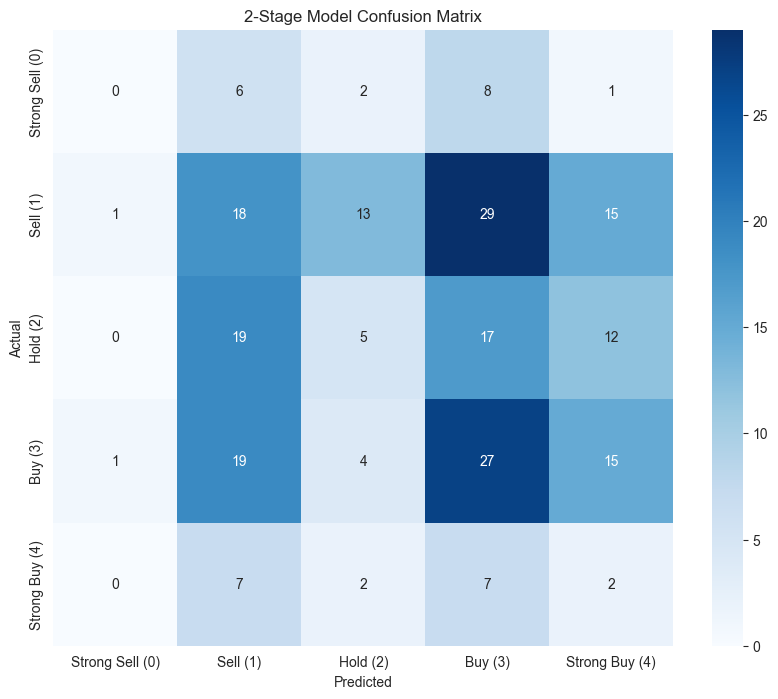

                 precision    recall  f1-score   support

Strong Sell (0)       0.00      0.00      0.00        17
       Sell (1)       0.26      0.24      0.25        76
       Hold (2)       0.19      0.09      0.13        53
        Buy (3)       0.31      0.41      0.35        66
 Strong Buy (4)       0.04      0.11      0.06        18

       accuracy                           0.23       230
      macro avg       0.16      0.17      0.16       230
   weighted avg       0.22      0.23      0.22       230



In [9]:
if model_s1 is not None:
    # Reconstruct Ground Truth 5-class labels for comparison
    # 0: < -5%, 1: -5%~-1%, 2: -1%~1%, 3: 1%~5%, 4: > 5%
    conditions = [
        (df_test['Future_Return'] > 0.05),
        (df_test['Future_Return'] > 0.01) & (df_test['Future_Return'] <= 0.05),
        (df_test['Future_Return'] >= -0.01) & (df_test['Future_Return'] <= 0.01),
        (df_test['Future_Return'] >= -0.05) & (df_test['Future_Return'] < -0.01),
        (df_test['Future_Return'] < -0.05)
    ]
    choices = [4, 3, 2, 1, 0]
    y_true = np.select(conditions, choices, default=2)
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, final_preds)
    target_names = ['Strong Sell (0)', 'Sell (1)', 'Hold (2)', 'Buy (3)', 'Strong Buy (4)']
    
    unique_labels = sorted(list(set(y_true) | set(final_preds)))
    present_names = [target_names[i] for i in unique_labels if i < len(target_names)]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=present_names, yticklabels=present_names)
    plt.title('2-Stage Model Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # Classification Report
    print(classification_report(y_true, final_preds, target_names=present_names, labels=unique_labels, zero_division=0))

## 4. Strategy Backtest (Strong Buy Only)

Does this new 2-stage model give us better signals?

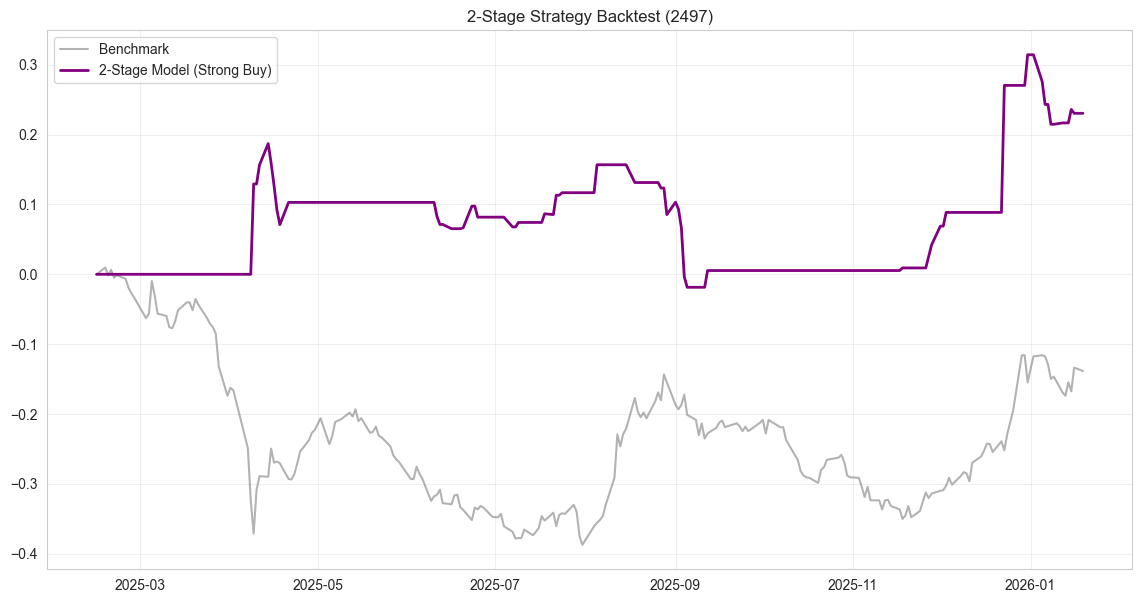

Total Strategy Return: 23.05%


In [13]:
if model_s1 is not None:
    # Strategy: Buy if Final Prediction is 4 (Strong Buy)
    df_test['Strategy_Return'] = np.where(df_test['Final_Prediction'] >= 4, df_test['Future_Return'], 0)
    df_test['Cumulative_Strategy'] = df_test['Strategy_Return'].cumsum()
    
    initial_price = df_test['Close'].iloc[0]
    df_test['Benchmark_Return'] = (df_test['Close'] - initial_price) / initial_price
    
    plt.figure(figsize=(14, 7))
    plt.plot(df_test.index, df_test['Benchmark_Return'], label='Benchmark', color='gray', alpha=0.6)
    plt.plot(df_test.index, df_test['Cumulative_Strategy'], label='2-Stage Model (Strong Buy)', color='purple', linewidth=2)
    plt.title(f"2-Stage Strategy Backtest ({STOCK_ID})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Total Strategy Return: {df_test['Cumulative_Strategy'].iloc[-1]:.2%}")